In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q /content/drive/MyDrive/image_intel/seg_train.zip -d /content/image_intel
!unzip -q /content/drive/MyDrive/image_intel/seg_test.zip -d /content/image_intel
!unzip -q /content/drive/MyDrive/image_intel/seg_pred.zip -d /content/image_intel

In [ ]:
# Import torch's neural network tools to process data and build the classification model
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [ ]:
torch.__version__

'2.10.0+cu128'

In [ ]:
# Import ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

## **1. Data (preparing and loading)**

# Load or check data (visualize, visualize, visualize!)

In [ ]:
import os

for dirpath, dirnames, filenames in os.walk("/content/image_intel/seg_train"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

for dirpath, dirnames, filenames in os.walk("/content/image_intel/seg_test"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

for dirpath, dirnames, filenames in os.walk("/content/image_intel/seg_pred"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

Train data path: /content/image_intel/seg_train
Train data directories length: 6
Train data filenames length: 0
Train data path: /content/image_intel/seg_train/street
Train data directories length: 0
Train data filenames length: 2382
Train data path: /content/image_intel/seg_train/sea
Train data directories length: 0
Train data filenames length: 2274
Train data path: /content/image_intel/seg_train/forest
Train data directories length: 0
Train data filenames length: 2271
Train data path: /content/image_intel/seg_train/buildings
Train data directories length: 0
Train data filenames length: 2191
Train data path: /content/image_intel/seg_train/mountain
Train data directories length: 0
Train data filenames length: 2512
Train data path: /content/image_intel/seg_train/glacier
Train data directories length: 0
Train data filenames length: 2404
Train data path: /content/image_intel/seg_test
Train data directories length: 6
Train data filenames length: 0
Train data path: /content/image_intel/seg_

In [ ]:
# View a random image by accessing its path
def view_image(target_dir, target_class):
    target_folder = target_dir + target_class

    random_img = random.sample(os.listdir(target_folder), 1)

    img = mpimg.imread(target_folder + "/" + random_img[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")

    return img

Image shape: (150, 150, 3)


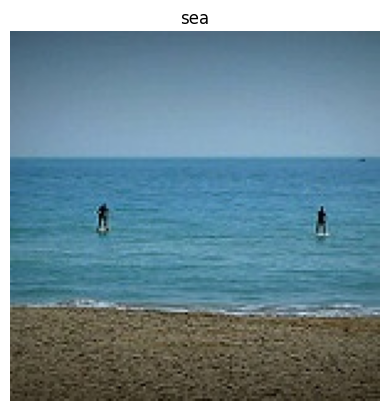

In [ ]:
# random image from train data - sea

img = view_image("/content/image_intel/seg_train/", "sea")
print(f"Image shape: {img.shape}")

In [ ]:
# Check multiple images by getting the class name from train path
import pathlib

data_dir = pathlib.Path("/content/image_intel/seg_train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


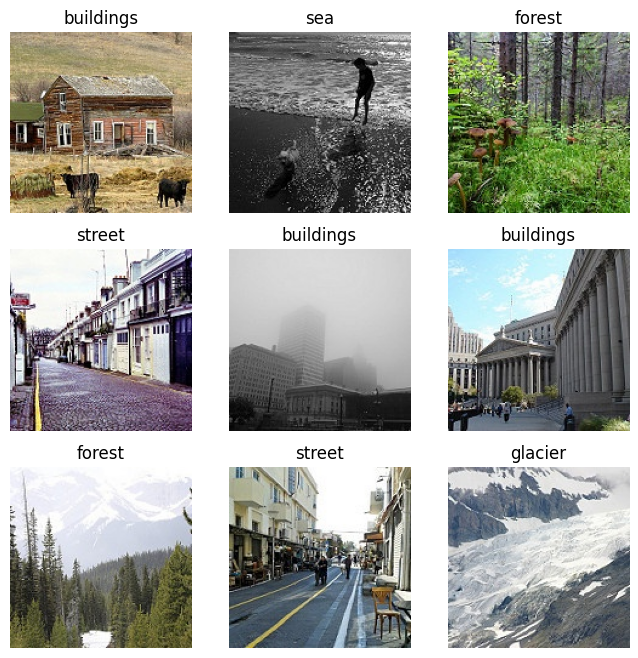

In [ ]:
# Plot random images
plt.figure(figsize=(8, 8))
for i in range(9):
    ax = plt.subplot(3, 3, i+1)
    class_name = random.choice(class_names)
    img = view_image("/content/image_intel/seg_train/", class_name)

# PREPARE DATA

In [ ]:
train_dir = "/content/image_intel/seg_train"
test_dir = "/content/image_intel/seg_test"

In [ ]:
# reshape and transform data from numpy.ndarray to tensor
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

train_transforms = transforms.Compose([transforms.Resize(IMAGE_SIZE),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.RandomRotation(degrees=10),
                                      transforms.ColorJitter(brightness=0.2, contrast=0.2),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                           std=[0.229, 0.224, 0.225])
                                      ])

test_transforms = transforms.Compose([transforms.Resize(IMAGE_SIZE),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                           std=[0.229, 0.224, 0.225])
                                      ])

train_data = ImageFolder(train_dir, transform=train_transforms)
test_data = ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_data,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=2)
test_loader = DataLoader(test_data,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=2)

In [ ]:
print(len(train_data))
print(len(test_data))

14034
3000


## **2. Building model - CNN (classification)**

In [ ]:
class ImageClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(10, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(10, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(10, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(10 * 37 * 37, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
model_0 = ImageClassifier(num_classes=len(class_names)).to(device)

In [ ]:
!pip install torchinfo

In [ ]:
# Get model summary
import torchinfo

torchinfo.summary(model=model_0)

Layer (type:depth-idx)                   Param #
ImageClassifier                          --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       280
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       910
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       910
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       910
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
├─Sequential: 1-2                        --
│    └─Flatten: 2-11                     --
│    └─Linear: 2-12                      82,146
Total params: 85,156
Trainable params: 85,156
Non-trainable params: 0

## **3. Train Model**

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model_0.parameters(),
                       lr=0.001)

In [ ]:
epochs = 15

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_0.train()
    loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        predictions = model_0(images)
        loss = loss_fn(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_loss = 0.0
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)

            test_pred = model_0(test_images)
            test_loss = loss_fn(test_pred, test_labels)

    epoch_count.append(epoch)
    loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())

    print(f"Epoch: {epoch+1} | Loss: {loss.item()} | Test Loss: {test_loss.item()}")

Epoch: 1 | Loss: 1.0002858638763428 | Test Loss: 0.9759599566459656
Epoch: 2 | Loss: 0.8759222030639648 | Test Loss: 0.7234832644462585
Epoch: 3 | Loss: 0.7879122495651245 | Test Loss: 0.8978236317634583
Epoch: 4 | Loss: 0.5760801434516907 | Test Loss: 0.6409977078437805
Epoch: 5 | Loss: 0.49403783679008484 | Test Loss: 0.6463409066200256
Epoch: 6 | Loss: 0.38647139072418213 | Test Loss: 0.8671846985816956
Epoch: 7 | Loss: 0.6166908144950867 | Test Loss: 1.0348409414291382
Epoch: 8 | Loss: 0.25757667422294617 | Test Loss: 0.5902704000473022
Epoch: 9 | Loss: 0.3896122872829437 | Test Loss: 0.8616544604301453
Epoch: 10 | Loss: 1.0992869138717651 | Test Loss: 0.6359221935272217
Epoch: 11 | Loss: 0.2177765965461731 | Test Loss: 0.6568627953529358
Epoch: 12 | Loss: 0.7291198968887329 | Test Loss: 0.614145815372467
Epoch: 13 | Loss: 0.3245246708393097 | Test Loss: 0.7446370124816895
Epoch: 14 | Loss: 0.29392528533935547 | Test Loss: 0.48231497406959534
Epoch: 15 | Loss: 0.37266895174980164 |

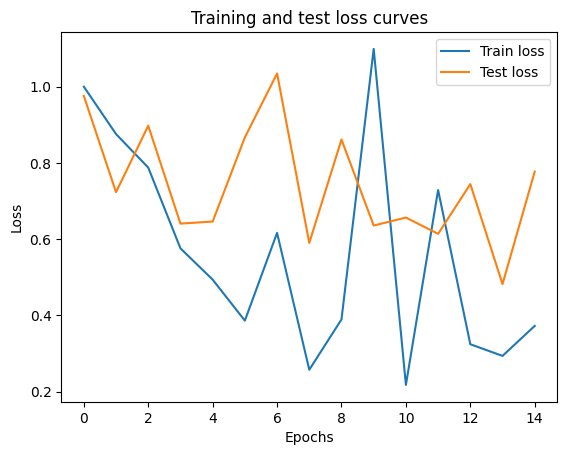

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
# Gather predicted and actual values
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_predictions(model, dataloader, device):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_predictions, all_labels

In [ ]:
train_labels, train_preds = get_predictions(model_0, train_loader, device)
test_labels, test_preds = get_predictions(model_0, test_loader, device)

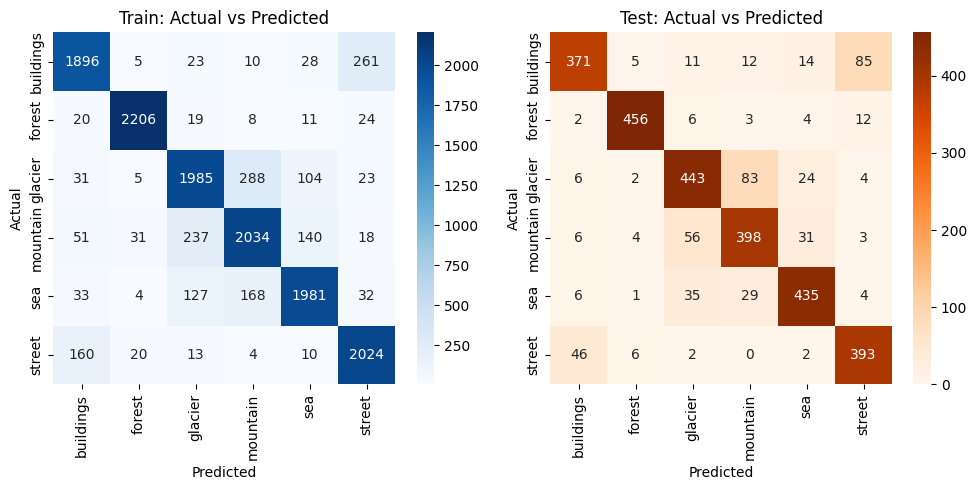

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Train Comparison
cm_train = confusion_matrix(train_labels, train_preds)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=class_names, yticklabels=class_names)
ax[0].set_title('Train: Actual vs Predicted')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Test Comparison
cm_test = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=ax[1], xticklabels=class_names, yticklabels=class_names)
ax[1].set_title('Test: Actual vs Predicted')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 4. **Saving and Loading the Model**

In [ ]:
# Saving model_0
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                exist_ok=True)

MODEL_NAME = "image_intel_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/image_intel_model_0.pth


In [ ]:
# Copy saved model to MyDrive
import shutil

DRIVE_PATH = Path("/content/drive/MyDrive/image_intel/models")
DRIVE_MODEL_PATH = DRIVE_PATH / MODEL_NAME

shutil.copy(MODEL_SAVE_PATH, DRIVE_MODEL_PATH)
print(f"Model saved to {DRIVE_MODEL_PATH}")

Model saved to /content/drive/MyDrive/image_intel/models/image_intel_model_0.pth


In [ ]:
# Loading model_0
loaded_model_0 = ImageClassifier(num_classes=len(class_names))

# Load the saved state_dict() of model_0
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_0.to(device)

ImageClassifier(
  (features): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=13690, out_features=6, bias=True)
  )
)

In [ ]:
# Make some predictions with the loaded model_0
from PIL import Image

def predict_image(image_path, model, transform, class_names):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).float().to(device)

    model.eval()
    with torch.inference_mode():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return class_names[pred], probs[0][pred].item()

image_path = "/content/image_intel/seg_pred/10017.jpg"
predicted_class, confidence = predict_image(image_path, loaded_model_0, test_transforms, class_names)
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence * 100:.2f}%")

Predicted class: glacier
Confidence: 56.86%
